## Imports & Config

In [30]:
import importlib

from meta_heuristics import meta_information
from meta_heuristics import  problem_instance
from meta_heuristics import  solution_instance
from meta_heuristics import  swap_2_player
from meta_heuristics import  simulated_annealing
importlib.reload(meta_information)
importlib.reload(problem_instance)
importlib.reload(solution_instance)
importlib.reload(swap_2_player)
importlib.reload(simulated_annealing)

from meta_information import MetaInformationPlotter, MetaInformation
from problem_instance import ProblemInstance
from solution_instance import SolutionInstance
from swap_2_player import Swap2Player
from simulated_annealing import SimulatedAnnealing

# Social Golfer Problem Config
NUM_GROUPS = 6
NUM_PLAYERS = 32
NUM_WEEKS = 8

# Simulated Annealing Config
INIT_TEMP = 400
FINAL_TEMP = 0.001
EQI_ITER = 20
ALPHA = 0.90

## Run Simulated Annealing

Violation Count: 116
Week 0:
  Group 0: [14, 8, 22, 31, 20]
  Group 1: [6, 18, 25, 0, 15]
  Group 2: [10, 30, 9, 21, 5]
  Group 3: [12, 11, 19, 24, 27]
  Group 4: [29, 26, 3, 1, 28]
  Group 5: [13, 4, 23, 17, 2]
Week 1:
  Group 0: [30, 23, 22, 11, 3]
  Group 1: [18, 17, 12, 5, 6]
  Group 2: [10, 25, 16, 0, 31]
  Group 3: [29, 27, 9, 19, 13]
  Group 4: [24, 26, 20, 28, 15]
  Group 5: [21, 7, 8, 1, 2]
Week 2:
  Group 0: [21, 24, 25, 6, 10]
  Group 1: [11, 2, 29, 19, 16]
  Group 2: [23, 22, 31, 7, 8]
  Group 3: [12, 3, 26, 14, 1]
  Group 4: [5, 18, 13, 0, 30]
  Group 5: [15, 4, 20, 17, 27]
Week 3:
  Group 0: [13, 0, 11, 27, 17]
  Group 1: [5, 20, 19, 10, 24]
  Group 2: [1, 6, 25, 3, 15]
  Group 3: [29, 21, 30, 9, 31]
  Group 4: [8, 14, 18, 22, 26]
  Group 5: [2, 23, 12, 28, 16]
Week 4:
  Group 0: [5, 0, 22, 10, 8]
  Group 1: [16, 21, 30, 9, 28]
  Group 2: [4, 29, 24, 13, 20]
  Group 3: [25, 6, 11, 3, 18]
  Group 4: [1, 31, 27, 17, 7]
  Group 5: [26, 15, 12, 19, 23]
Week 5:
  Group 0: [13,

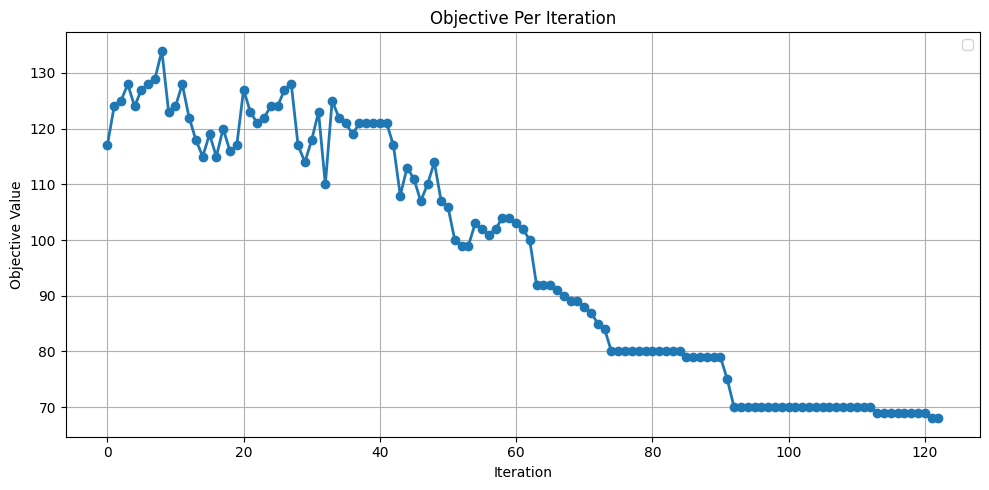

In [31]:
problem_instance = ProblemInstance(NUM_GROUPS,NUM_PLAYERS,NUM_WEEKS)
neighborhood = Swap2Player()
solution_instance = SolutionInstance(problem_instance, SolutionInstance.generate_random_solution, neighborhood)
print(solution_instance)
sa_solver = SimulatedAnnealing(
    solution_instance,
    init_temperature=INIT_TEMP,
    final_temperature=FINAL_TEMP,
    equilibrium_iterations=EQI_ITER,
    alpha=ALPHA)


meta_infos = []
best_solution = sa_solver.solve()
print(f"Best solution found with {best_solution.count_violations()} violations: \n{best_solution}")
meta_infos.append(sa_solver.meta_inf)

MetaInformationPlotter.plot_meta_info(meta_infos=meta_infos)